# Exercise 3 - Kraftwerkseinsatzplanung

VU - Energiemodelle und Analysen

Gruppe 10 - Hannah Bennoui, Peter Geyrhofer, Johannes Tanzer, Clemens Stadler

## Parameter und Vorbereitung

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import gurobipy as gp
from gurobipy import GRB

In [2]:
# Import der .csv Datei und Umwandelung in pandas-dataframe

df_load = pd.read_csv('Last_PV_Wind.csv', sep=';')

In [3]:
# Parameterdefinition

power_coal = 600 #MW
power_gud = 400 #MW
power_gas = 300 #MW
power_pumps = 200 #MW
power_PV_inst = 100 #MW
power_wind_inst = 300 #MW
power_wind = df_load['Wind 300 MW'].values
power_PV = df_load['PV 100 MW Winter'].values
eta_coal = 0.41
eta_gud = 0.58
eta_gas = 0.4
eta_turbine = 0.9
eta_pump = 0.9
fuelcost_coal = 10 #€/MWh
fuelcost_gas = 45 #€/MWh
CO2_coal = 0.35 #%
CO2_ngas = 0.2 #%
CO2_price = 80 #€/t
capacity_pumps = 600 #MWh
H_coal = 8 # MWh/t
H_ngas = 14 # MWh/t
T = 24

In [4]:
# Berechnung der Marginal Costs

mc_coal = fuelcost_coal/(eta_coal*H_coal)+(CO2_price*CO2_coal)/eta_coal
mc_gud = fuelcost_gas/(eta_gud*H_ngas)+(CO2_price*CO2_ngas)/eta_gud
mc_gas = fuelcost_gas/(eta_gas*H_ngas)+(CO2_price*CO2_ngas)/eta_gas
mc_pumps = 0
mc_PV = 0
mc_Wind = 0

print(round(mc_gas,2),round(mc_gud,2),round(mc_coal,2))

48.04 33.13 71.34


In [5]:
# CO2-Ausstoß bezogen auf den Brennstoffverbrauch bzw. Wirkungsgrad

CO2_coal = CO2_coal/eta_coal
CO2_gas = CO2_ngas/eta_gas
CO2_gud = CO2_ngas/eta_gud

## Task 1 - Fossile Erzeugung

### a) Kraftwerkseinsatzoptimierung

In [6]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["GuD", "Gasturbine", "Kohle"]
n_units = 3  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']
co2_faktoren = [CO2_gud, CO2_gas, CO2_coal]
mc = [[mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit
p_max = [power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        p[i, t] = model.addVar(lb=0, ub=p_max[i], name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

# Plot
if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")
        constr = model.getConstrByName(f"load_{t}")
        if constr is not None:
            strompreis = constr.Pi
            print(f"  Strompreis: {strompreis:.2f} €/MWh")
            strompreis_liste.append({
                "Stunde": t,
                "Strompreis [€/MWh]": strompreis
            })

Restricted license - for non-production use only - expires 2026-11-23
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 24 rows, 72 columns and 72 nonzeros
Model fingerprint: 0xea8612df
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+01]
  Bounds range     [3e+02, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 19 rows and 57 columns
Presolve time: 0.01s
Presolved: 5 rows, 15 columns, 15 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.1473348e+06   1.525000e+02   0.000000e+00      0s
       5    1.1655221e+06   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.165522065e+06
Stunde 0:
  GuD: 400.00 MW
  Gasturbine: 300.0

In [7]:
# Speichern der Ergebnisse in dataframe und Berechnung der Kosten und CO2-Emission pro Stunde

ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X  # MW
        kosten = mc[i][t] * leistung
        emission = co2_faktoren[i] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission,
        })
df_res = pd.DataFrame(ergebnisse)

In [8]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_res["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 1165522.07 €
Gesamtemissionen: 12933.76 Tonnen CO2


### b) Grafische Darstellung der Situation

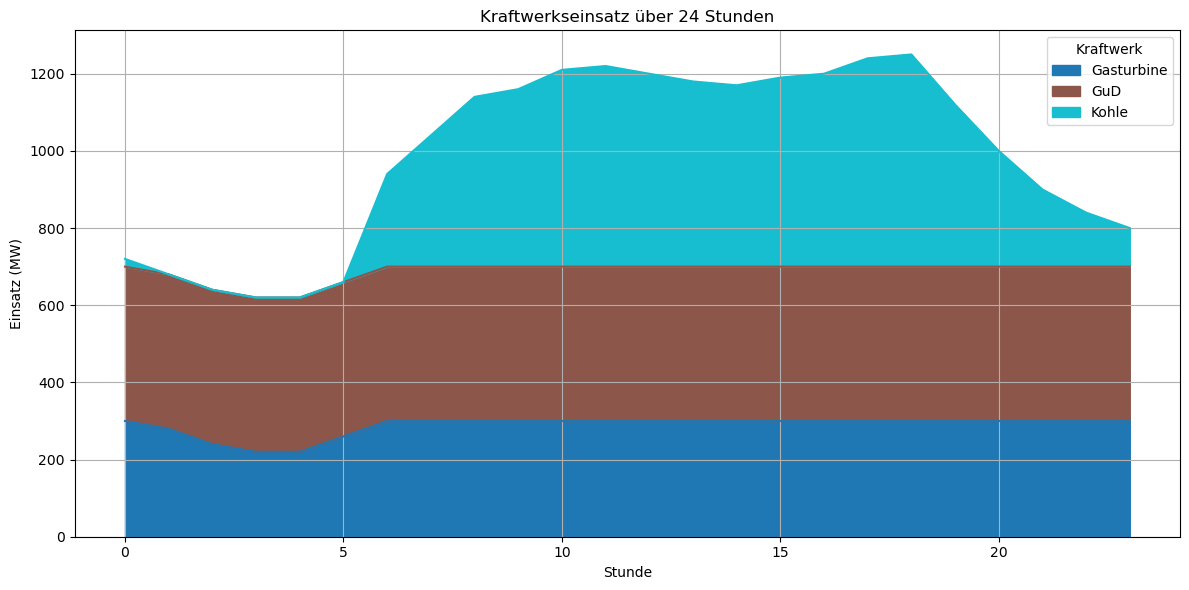

In [9]:
# Grafische Darstellung des Kraftwerkseinsatzes

df_utilization = df_res.pivot(index="Stunde", columns="Kraftwerk", values="Einsatz (MW)")

df_utilization.plot.area(figsize=(12, 6), cmap="tab10")
plt.title("Kraftwerkseinsatz über 24 Stunden")
plt.xlabel("Stunde")
plt.ylabel("Einsatz (MW)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

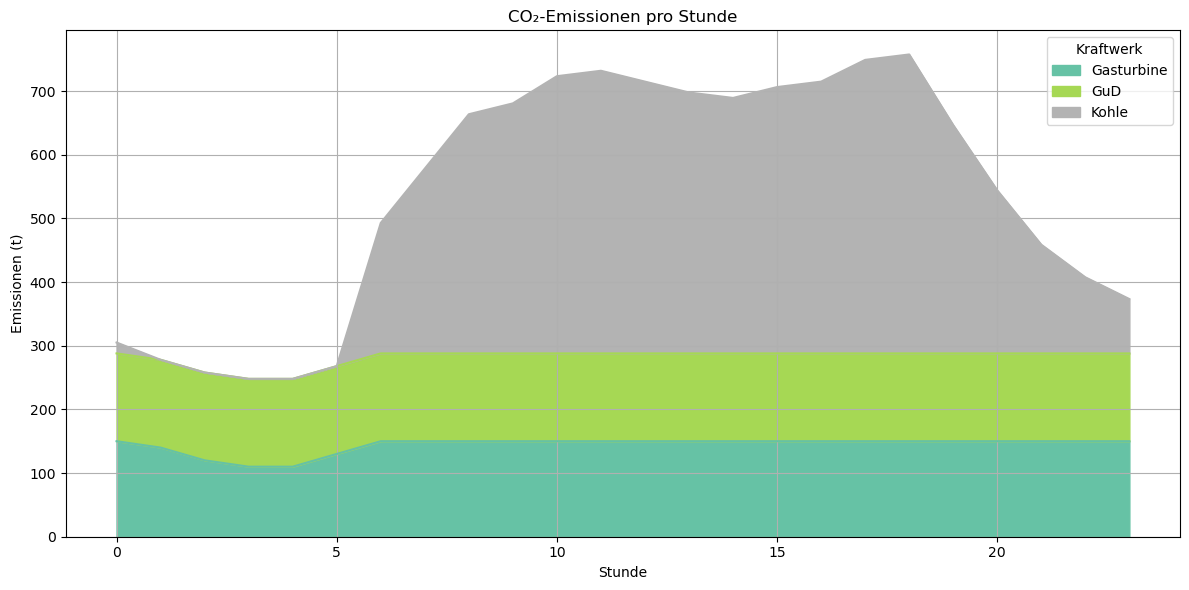

In [10]:
# Grafische Darstellung der CO2-Emissionen pro Stunde

df_emission = df_res.pivot(index="Stunde", columns="Kraftwerk", values="CO2 (t)")
df_emission.plot.area(figsize=(12, 6), cmap="Set2")
plt.title("CO₂-Emissionen pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Emissionen (t)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

### c) Interpretation der Schattenvariable

Die Schattenvariable der Lastdeckungsbedingung gibt an, wie stark sich der Zielfunktionswert (z. B. Gesamtkosten) verändert, wenn die elektrische Last um eine Einheit (1 MWh) erhöht wird. In der Energiewirtschaft entspricht sie damit dem Grenzpreis für Strom in der jeweiligen Stunde.

Im betrachteten Modell stellt die Lastdeckungsbedingung sicher, dass zu jedem Zeitpunkt die Summe der eingesetzten Erzeugungsleistung (später inkl. Speicher) mindestens der Nachfrage entspricht. Ist diese Bedingung aktiv, lässt sich die Schattenvariable als stündlicher Strompreis interpretieren, da sie den Wert einer zusätzlichen MWh im System angibt.

Theoretisch könnten diese Werte in einem LP-basierten Pyomo-Modell nach der Optimierung über ein `Suffix`-Objekt ausgelesen werden:

model.dual = Suffix(direction=Suffix.IMPORT)
solver.solve(model)
preis = model.dual[model.lastdeckung_constraint[t]]

**Um direkt auf Gurobi-Funktionen zugreifen zu können und den Code kompakt zu halten, wurde hier die gurobipy-datenbank anstatt Pyomo verwendet.**


### d) Strompreis pro Stunde

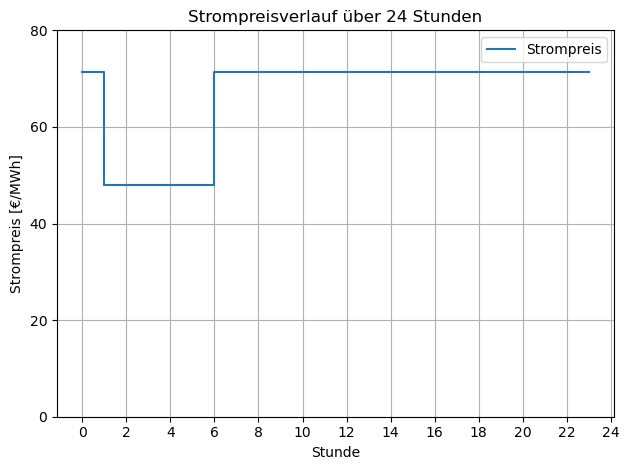

In [11]:
# Grafische Darstellung der Schattenvariable

df_shadow = pd.DataFrame(strompreis_liste)

plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

## Task 2 - Erneuerbare Erzeugung

### a) Kraftwerkseinsatzoptimierung

In [12]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
n_units = 5  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]
mc = [[mc_Wind]*T,[mc_PV]*T, [mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit 
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
        if i == 0:
            ub = power_wind[t]  # Wind
        elif i == 1:
            ub = power_PV[t]    # PV
        else:
            ub = p_max[i]       # Konstante für konventionelle Kraftwerke
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

# Plot
if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")
        constr = model.getConstrByName(f"load_{t}")
        if constr is not None:
            strompreis = constr.Pi
            print(f"  Strompreis: {strompreis:.2f} €/MWh")
            strompreis_liste.append({
                "Stunde": t,
                "Strompreis [€/MWh]": strompreis
            })

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0xe0160ec2
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 16 rows and 88 columns
Presolve time: 0.00s
Presolved: 8 rows, 32 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.0350760e+05   5.667500e+02   0.000000e+00      0s
       8    9.7359709e+05   0.000000e+00   0.000000e+00      0s

Solved in 8 iterations and 0.01 seconds (0.00 work units)
Optimal objective  9.735970915e+05
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 160.00 MW
  Kohle: 0.00 MW
  Strompreis: 

In [13]:
# Speichern der Ergebnisse in dataframe und Berechnung der Kosten und CO2-Emission pro Stunde

ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X  # MW
        kosten = mc[i][t] * leistung
        emission = co2_faktoren[i] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission,
        })
df_res = pd.DataFrame(ergebnisse)

In [14]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_res["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 973597.09 €
Gesamtemissionen: 10696.0 Tonnen CO2


### b) Grafische Darstellung der Situation

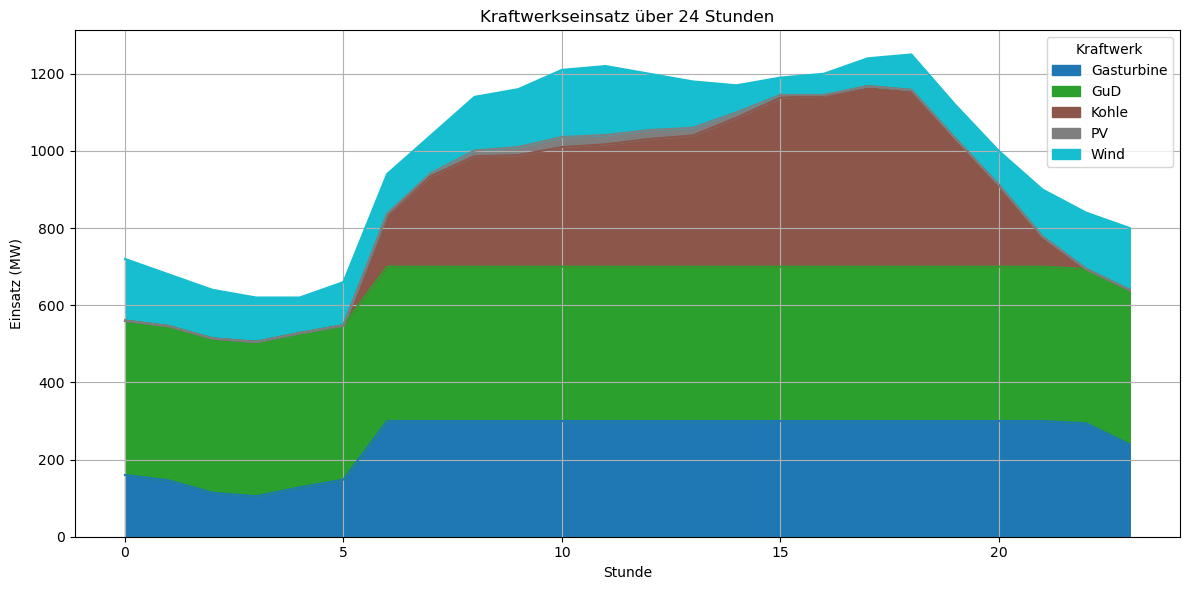

In [15]:
# Grafische Darstellung des Kraftwerkseinsatzes

df_utilization = df_res.pivot(index="Stunde", columns="Kraftwerk", values="Einsatz (MW)")

# Plot
df_utilization.plot.area(figsize=(12, 6), cmap="tab10")
plt.title("Kraftwerkseinsatz über 24 Stunden")
plt.xlabel("Stunde")
plt.ylabel("Einsatz (MW)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

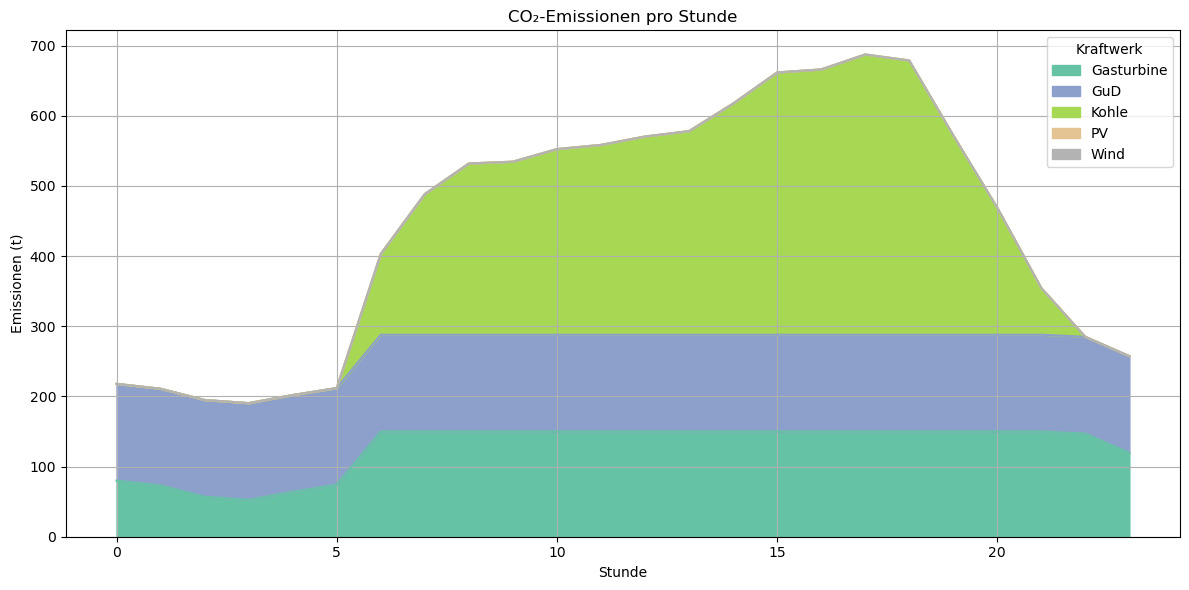

In [16]:
# Grafische Darstellung der CO2-Emissionen pro Stunde

df_emission = df_res.pivot(index="Stunde", columns="Kraftwerk", values="CO2 (t)")

df_emission.plot.area(figsize=(12, 6), cmap="Set2")
plt.title("CO₂-Emissionen pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Emissionen (t)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

### c) Strompreis pro Stunde

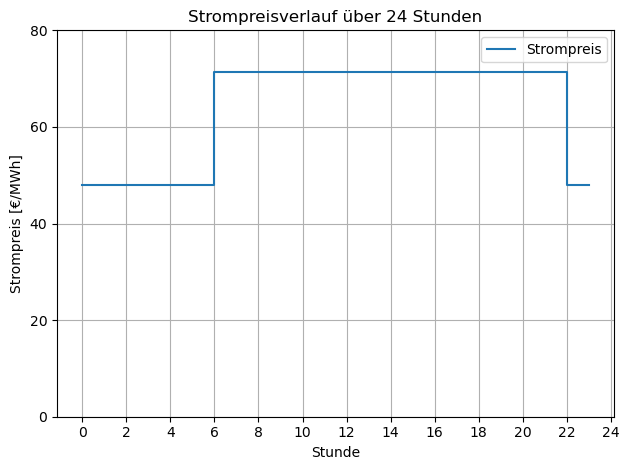

In [17]:
# Grafische Darstellung der Schattenvariable

df_shadow = pd.DataFrame(strompreis_liste)

plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

Vergleicht man das Ergebnis mit Task 1, wird klar, dass durch die zusätzliche Einspeisung der Erneuerbaren der Strompreis insgesamt sinkt (sprich: der Wert 48 kommt öfter vor als zuvor). Unter Tags ist jedoch kaum eine Veränderung ersichtlich, da die installierte PV-Leistung gering ist und es sich um einen Wintertag handelt.

## Task 3 - Speicher

### a) Kraftwerkseinsatzoptimierung

In [18]:
# Modell initialisieren
model = gp.Model("kraftwerkseinsatz_mit_speicher")

kraftwerksnamen = ["Wind", "PV", "GuD", "Gasturbine", "Kohle"]
n_units = 5

mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]
load = df_load["Last Winter [MW]"]
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Variablen definieren
p = {}
charge = {}
discharge = {}
soc = {}

for t in range(T):
    for i in range(n_units):
        ub = p_max[i][t] if i < 2 else p_max[i]
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

    charge[t] = model.addVar(lb=0, ub=power_pumps, name=f"charge_{t}")
    discharge[t] = model.addVar(lb=0, ub=power_pumps, name=f"discharge_{t}")
    soc[t] = model.addVar(lb=0, ub=capacity_pumps, name=f"soc_{t}")

# Speicherbilanz über die Zeit
for t in range(T):
    if t == 0:
        model.addConstr(soc[t] == eta_pump * charge[t] - discharge[t] / eta_turbine)
    else:
        model.addConstr(soc[t] == soc[t-1] + eta_pump * charge[t] - discharge[t] / eta_turbine)

# Lastdeckung (mit Speicher)
for t in range(T):
    model.addConstr(
        gp.quicksum(p[i, t] for i in range(n_units)) + discharge[t] == load[t] + charge[t],
        name=f"load_{t}"
    )

# Zielfunktion: Minimale Kosten inkl. optionaler Speicherbetriebskosten
storage_cost = 1  # optional - wurde nur symbolisch hinzugefügt
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)) +
    gp.quicksum(storage_cost * (charge[t] + discharge[t]) for t in range(T)),
    GRB.MINIMIZE
)

# Optimierung starten
model.optimize()

# Ergebnisse speichern
strompreis_liste = []

#Plot
if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            print(f"  {kraftwerksnamen[i]}: {p[i, t].X:.2f} MW")
        print(f"  Speicherladung: {charge[t].X:.2f} MW")
        print(f"  Speicherentladung: {discharge[t].X:.2f} MW")
        print(f"  Speicherfüllstand: {soc[t].X:.2f} MWh")

        strompreis = model.getConstrByName(f"load_{t}").Pi
        print(f"  Strompreis: {strompreis:.2f} €/MWh")
        strompreis_liste.append({"Stunde": t, "Strompreis [€/MWh]": strompreis})


Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 48 rows, 192 columns and 263 nonzeros
Model fingerprint: 0x345b6fe1
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 7e+01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 10 rows and 90 columns
Presolve time: 0.00s
Presolved: 38 rows, 102 columns, 153 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.8816468e+05   9.907236e+02   0.000000e+00      0s
      41    9.6830318e+05   0.000000e+00   0.000000e+00      0s

Solved in 41 iterations and 0.01 seconds (0.00 work units)
Optimal objective  9.683031774e+05
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 0.00 MW
  Speicher

In [19]:
einsatz_daten = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X
        kosten = mc[i][t] * leistung
        einsatz_daten.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten
        })

    # Speicher (optional mit Speicherbetriebskosten, z. B. 1 €/MWh)
    speicher_kosten = 1.0

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Entladung)",
        "Einsatz (MW)": discharge[t].X,
        "Kosten (€)": speicher_kosten * discharge[t].X
    })

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Ladung)",
        "Einsatz (MW)": -charge[t].X,  # negativ als Ladebedarf
        "Kosten (€)": speicher_kosten * charge[t].X
    })

df_utilization = pd.DataFrame(einsatz_daten)


In [20]:
strompreis_daten = []

for t in range(T):
    strompreis = model.getConstrByName(f"load_{t}").Pi
    strompreis_daten.append({
        "Stunde": t,
        "Strompreis [€/MWh]": strompreis
    })

df_shadow = pd.DataFrame(strompreis_daten)

In [21]:
emissions_daten = []

for t in range(T):
    for i in range(n_units):
        if co2_faktoren[i] > 0:
            emissions_daten.append({
                "Stunde": t,
                "Kraftwerk": kraftwerksnamen[i],
                "CO2 (t)": co2_faktoren[i] * p[i, t].X
            })

df_emissions = pd.DataFrame(emissions_daten)

In [22]:
print("Gesamtkosten:", round(df_utilization["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_emissions["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 968303.18 €
Gesamtemissionen: 10568.36 Tonnen CO2


### b) Mathematische Modellierung

**Entscheidungsvariablen**

- $p_{i,t}$: Leistung des Kraftwerks *i* zur Zeit *t* [MW]  
- $p^\text{in}_t$: Ladeleistung des Speichers zur Zeit *t* [MW]  
- $p^\text{out}_t$: Entladeleistung des Speichers zur Zeit *t* [MW]  
- $s_t$: Speicherfüllstand zur Zeit *t* [MWh]  

---

**Parameter**

- $L_t$: Last in Stunde *t* [MW]  
- $p^{\max}_{i,t}$: Max. Leistung des Kraftwerks *i* zu Zeit *t*  
- $p^\text{in}_{\max}$, $p^\text{out}_{\max}$: Max. Lade-/Entladeleistung [MW]  
- $\eta_\text{in}$, $\eta_\text{out}$: Lade-/Entlade-Wirkungsgrade  
- $s_{\max}$: Speichergröße [MWh]  
- $c_i$: Brennstoffkosten von Kraftwerk *i* [€/MWh]  
- $e_i$: Emissionsfaktor [t CO₂ / MWh]  
- $\text{CO2\_price}$: CO₂-Preis [€/t]  

---

**Zielfunktion**

Minimiere die Gesamtkosten:

$$
\min \sum_{t=1}^T \sum_{i=1}^N \left( c_i + \text{CO2\_price} \cdot e_i \right) \cdot p_{i,t}
$$

---

**Nebenbedingungen**

1. Lastdeckung:

$$
\sum_{i=1}^N p_{i,t} + p^\text{out}_t - p^\text{in}_t = L_t \quad \forall t
$$

2. Erzeugungsgrenzen:

$$
0 \leq p_{i,t} \leq p^{\max}_{i,t} \quad \forall i, t
$$

3. Lade- und Entladegrenzen:

$$
0 \leq p^\text{in}_t \leq p^\text{in}_{\max} \quad \forall t
$$

$$
0 \leq p^\text{out}_t \leq p^\text{out}_{\max} \quad \forall t
$$

4. Speicherfüllstandsdynamik:

$$
s_t = s_{t-1} + \eta_\text{in} \cdot p^\text{in}_t - \frac{1}{\eta_\text{out}} \cdot p^\text{out}_t \quad \forall t > 0
$$

5. Speicherbegrenzung:

$$
0 \leq s_t \leq s_{\max} \quad \forall t
$$

6. Zyklische Bedingung (Endfüllstand = Anfangsfüllstand):

$$
s_T = s_0
$$

**Anmerkung:** Diese Auflistung soll das Modell möglichst vollständig beschreiben und einen Überblick liefern. Wie in a) ersichtlich ist, wurde es jedoch nicht 1:1 so implementiert. Es wurde angenommen, dass der Speicher nur 1x geladen und 1x entladen werden kann, daher wurde die 6. Bedingung nicht direkt in der Form übergeben. Weiters wurden begrenzende Nebenbedingungen z.T. nicht verwendet, da die Grenzen ohnehin im ersten Kapitel hardcoded sind.


### c) Auswirkung auf Emissionen

Ersichtlich ist, dass sowohl der Gesamtkosten, als auch die CO2-Emissionen mit dem Speicher sinken. Dies liegt daran, dass in Stunden mit geringem Strompreis die noch vorhandenen Kapazitäten des preissetzenden Kraftwerks (GuD) verwendet wurden um den Speicher zu füllen. Die Entladung des Speichers erfolgt wenn der Preis hoch ist (da der Speicher im Arbitragebetrieb arbeitet) - somit sinken die Gesamtkosten. Die Gesamtemissionen sinken, da die zusätzliche Erzeugung durch das GuD-Kraftwerk emissionsärmer ist, als eine alternative Erzeugung mit Kohle.

### d) Strompreis pro Stunde

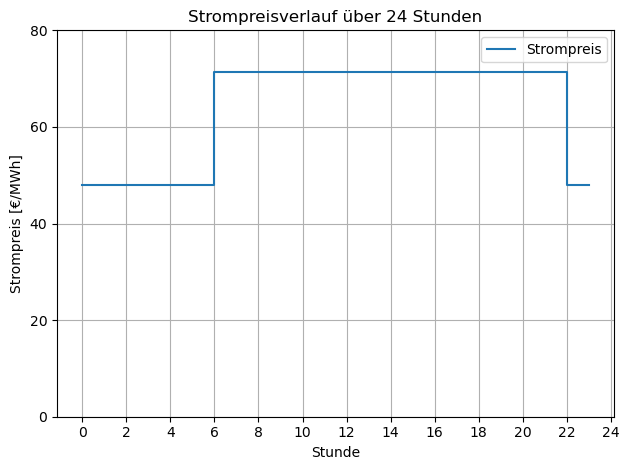

In [23]:
# Grafische Darstellung des Strompreises
plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

Wie im Diagramm ersichtlich ist, wurde der Speicher als nicht preissetzend angenommen und befindet sich im Arbitragebetrieb (=Strompreiskurve bleibt gleich). Wäre ein soziales Optimum durch den Speicher gefordert, könnte das Ausspeichern an einen anderen Zeitpunkt verlagert werden und der Strompreis länger auf 48 € behalten werden.

### e) Vergleich mit Task 1 und Task2

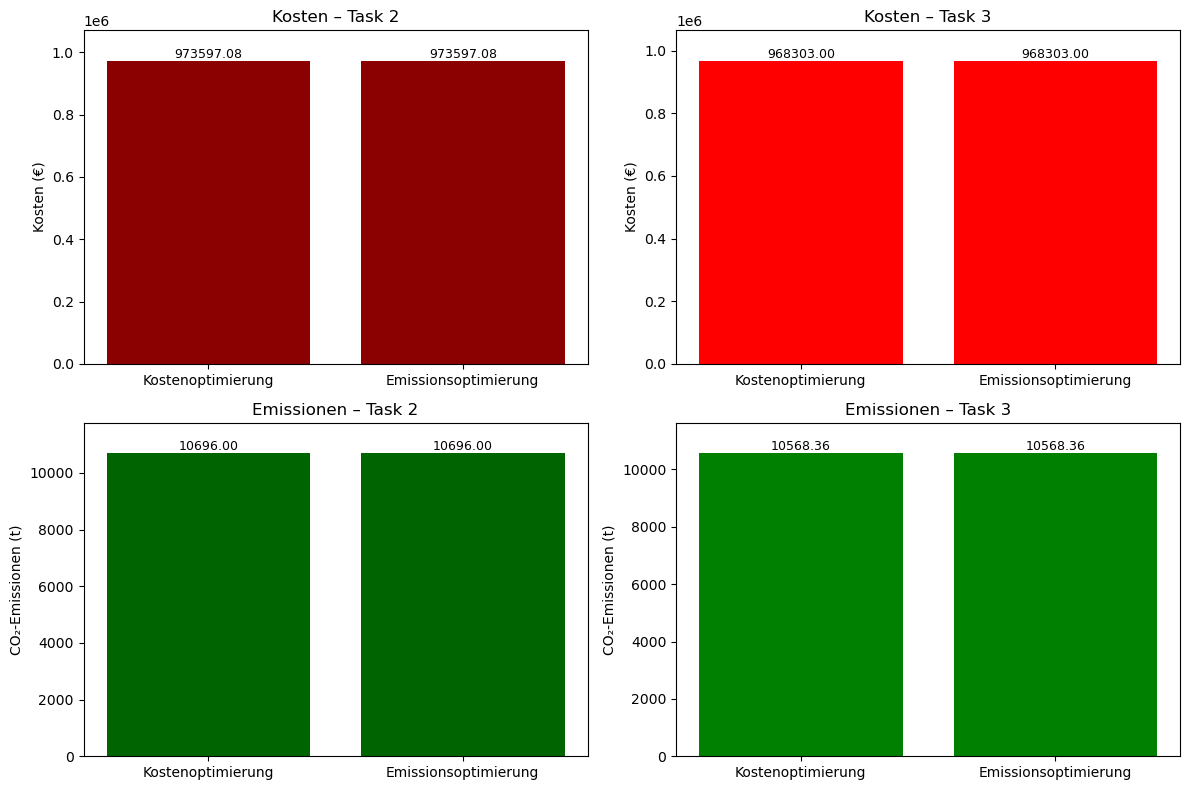

In [ ]:
import matplotlib.pyplot as plt

# Daten
tasks = ["Kostenoptimierung", "Emissionsoptimierung"]
kosten2 = [973597.08, 973597.08]
kosten3 = [968303, 968303]
emissionen2 = [10696, 10696]
emissionen3 = [10568.36, 10568.36]

# Erstellen der Subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Balkenbeschriftung
def annotate_bars(ax, values):
    for i, value in enumerate(values):
        ax.text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 1: Kosten Task 2
axs[0, 0].bar(tasks, kosten2, color="darkred")
axs[0, 0].set_title("Kosten – Task 2")
axs[0, 0].set_ylabel("Kosten (€)")
axs[0, 0].set_ylim(0, max(kosten2) * 1.1)
annotate_bars(axs[0, 0], kosten2)

# Plot 2: Emissionen Task 2
axs[1, 0].bar(tasks, emissionen2, color="darkgreen")
axs[1, 0].set_title("Emissionen – Task 2")
axs[1, 0].set_ylabel("CO₂-Emissionen (t)")
axs[1, 0].set_ylim(0, max(emissionen2) * 1.1)
annotate_bars(axs[1, 0], emissionen2)

# Plot 3: Kosten Task 3
axs[0, 1].bar(tasks, kosten3, color="red")
axs[0, 1].set_title("Kosten – Task 3")
axs[0, 1].set_ylabel("Kosten (€)")
axs[0, 1].set_ylim(0, max(kosten3) * 1.1)
annotate_bars(axs[0, 1], kosten3)

# Plot 4: Emissionen Task 3
axs[1, 1].bar(tasks, emissionen3, color="green")
axs[1, 1].set_title("Emissionen – Task 3")
axs[1, 1].set_ylabel("CO₂-Emissionen (t)")
axs[1, 1].set_ylim(0, max(emissionen3) * 1.1)
annotate_bars(axs[1, 1], emissionen3)

# Layout anpassen
plt.tight_layout()
plt.show()


Ersichtlich ist, dass (wie bereits erwähnt), sowohl Kosten, als auch Emissionen sinken. Logischerweise ist dies auch im Schritt von Task 1 auf 2 der Fall, da Erneuerbare mit MC=0 und Emissionen = 0 angenommen wurden.

## Task 4 - Kosten vs Emissionen

### a) Minimierung der CO2-Emissionen statt den Kosten

#### ohne Speicher - Task 2

In [25]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
n_units = 5  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]
mc = [[mc_Wind]*T,[mc_PV]*T, [mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
        if i == 0:
            ub = power_wind[t]  # Wind
        elif i == 1:
            ub = power_PV[t]    # PV
        else:
            ub = p_max[i]       # Konstante für konventionelle Kraftwerke
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(co2_faktoren[i] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

# Plot
if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0x37cbb946
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-01, 9e-01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 16 rows and 88 columns
Presolve time: 0.00s
Presolved: 8 rows, 32 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.9255551e+03   5.667500e+02   0.000000e+00      0s
       8    1.0696003e+04   0.000000e+00   0.000000e+00      0s

Solved in 8 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.069600336e+04
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 160.00 MW
  Kohle: 0.00 MW
Stunde 1:
  Wi

In [26]:
ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X
        emission = co2_faktoren[i] * leistung
        kosten = mc[i][t] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission
        })
df_res = pd.DataFrame(ergebnisse)


In [27]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_res["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 973597.09 €
Gesamtemissionen: 10696.0 Tonnen CO2


#### Modell 3 - mit Speicher

In [28]:
# Modell initialisieren

model = gp.Model("kraftwerkseinsatz_mit_speicher")
kraftwerksnamen = ["Wind", "PV", "GuD", "Gasturbine", "Kohle"]
n_units = 5

mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]
load = df_load["Last Winter [MW]"]
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Variablen definieren
p = {}
charge = {}
discharge = {}
soc = {}

for t in range(T):
    for i in range(n_units):
        ub = p_max[i][t] if i < 2 else p_max[i]
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

    charge[t] = model.addVar(lb=0, ub=power_pumps, name=f"charge_{t}")
    discharge[t] = model.addVar(lb=0, ub=power_pumps, name=f"discharge_{t}")
    soc[t] = model.addVar(lb=0, ub=capacity_pumps, name=f"soc_{t}")

# Speicherbilanz über die Zeit
for t in range(T):
    if t == 0:
        model.addConstr(soc[t] == eta_pump * charge[t] - discharge[t] / eta_turbine)
    else:
        model.addConstr(soc[t] == soc[t-1] + eta_pump * charge[t] - discharge[t] / eta_turbine)

# Lastdeckung (mit Speicher)
for t in range(T):
    model.addConstr(
        gp.quicksum(p[i, t] for i in range(n_units)) + discharge[t] == load[t] + charge[t],
        name=f"load_{t}"
    )

# Zielfunktion: Minimale Kosten inkl. optionaler Speicherbetriebskosten
storage_cost = 1  # optional
model.setObjective(
    gp.quicksum(co2_faktoren[i] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)
# Optimierung starten
model.optimize()

# Ergebnisse speichern
strompreis_liste = []

#Plot
if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            print(f"  {kraftwerksnamen[i]}: {p[i, t].X:.2f} MW")
        print(f"  Speicherladung: {charge[t].X:.2f} MW")
        print(f"  Speicherentladung: {discharge[t].X:.2f} MW")
        print(f"  Speicherfüllstand: {soc[t].X:.2f} MWh")


Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 48 rows, 192 columns and 263 nonzeros
Model fingerprint: 0xa225c1c8
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [3e-01, 9e-01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 10 rows and 90 columns
Presolve time: 0.00s
Presolved: 38 rows, 102 columns, 153 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.3284809e+03   2.269895e+03   0.000000e+00      0s
      22    1.0568361e+04   0.000000e+00   0.000000e+00      0s

Solved in 22 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.056836109e+04
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 0.00 MW
  Speicher

In [29]:
einsatz_daten = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X
        kosten = mc[i][t] * leistung
        einsatz_daten.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten
        })

    # Speicher (optional mit Speicherbetriebskosten, z. B. 1 €/MWh)
    speicher_kosten = 1.0

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Entladung)",
        "Einsatz (MW)": discharge[t].X,
        "Kosten (€)": speicher_kosten * discharge[t].X
    })

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Ladung)",
        "Einsatz (MW)": -charge[t].X,  # negativ als Ladebedarf
        "Kosten (€)": speicher_kosten * charge[t].X
    })

df_utilization = pd.DataFrame(einsatz_daten)


In [30]:
emissions_daten = []

for t in range(T):
    for i in range(n_units):
        if co2_faktoren[i] > 0:
            emissions_daten.append({
                "Stunde": t,
                "Kraftwerk": kraftwerksnamen[i],
                "CO2 (t)": co2_faktoren[i] * p[i, t].X
            })

df_emissions = pd.DataFrame(emissions_daten)

In [31]:
print("Gesamtkosten:", round(df_utilization["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_emissions["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 968303.18 €
Gesamtemissionen: 10568.36 Tonnen CO2


### b) Grafische Darstellung der Ergebnisse

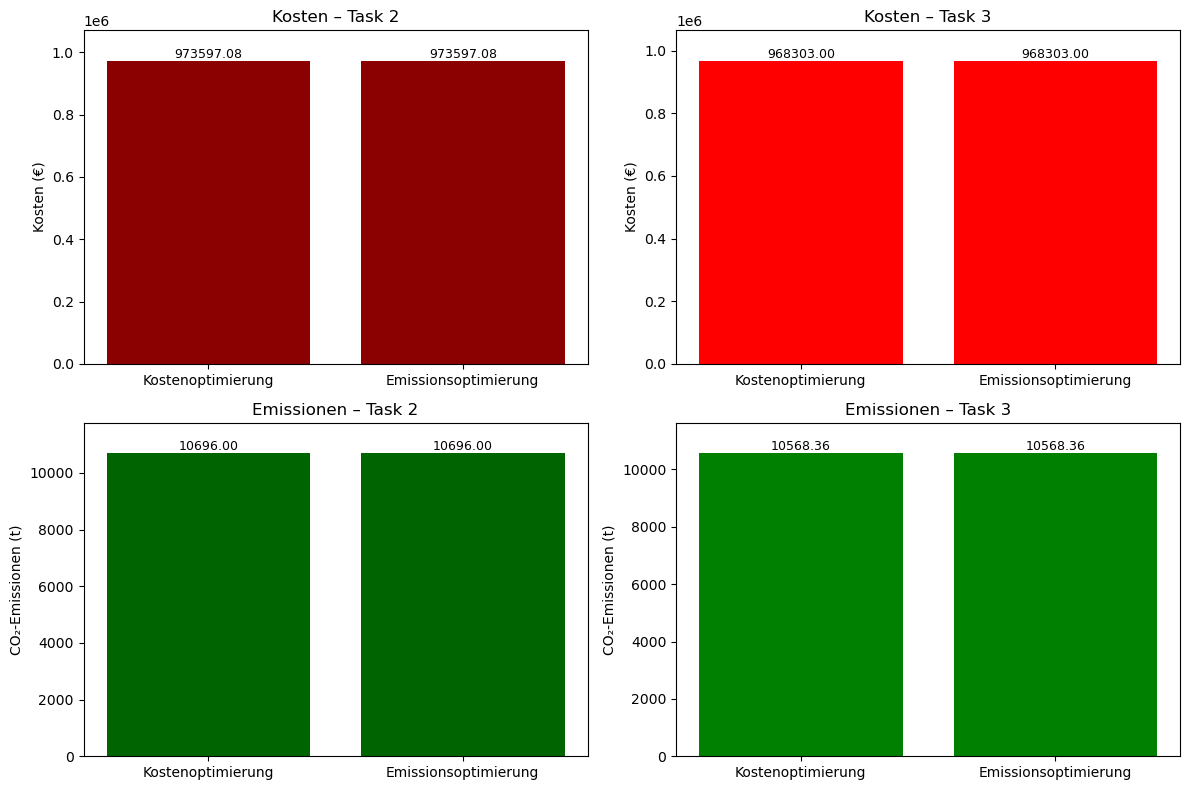

In [32]:
# Daten
tasks = ["Kostenoptimierung", "Emissionsoptimierung"]
kosten2 = [973597.08, 973597.08]
kosten3 = [968303, 968303]
emissionen2 = [10696, 10696]
emissionen3 = [10568.36, 10568.36]

# Erstellen der Subplots (2 Zeilen, 2 Spalten)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Funktion zum Beschriften der Balken
def annotate_bars(ax, values):
    for i, value in enumerate(values):
        ax.text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)
        
# Plot 1: Kosten Task 2
axs[0, 0].bar(tasks, kosten2, color="darkred")
axs[0, 0].set_title("Kosten – Task 2")
axs[0, 0].set_ylabel("Kosten (€)")
axs[0, 0].set_ylim(0, max(kosten2) * 1.1)
annotate_bars(axs[0, 0], kosten2)

# Plot 2: Emissionen Task 2
axs[1, 0].bar(tasks, emissionen2, color="darkgreen")
axs[1, 0].set_title("Emissionen – Task 2")
axs[1, 0].set_ylabel("CO₂-Emissionen (t)")
axs[1, 0].set_ylim(0, max(emissionen2) * 1.1)
annotate_bars(axs[1, 0], emissionen2)

# Plot 3: Kosten Task 3
axs[0, 1].bar(tasks, kosten3, color="red")
axs[0, 1].set_title("Kosten – Task 3")
axs[0, 1].set_ylabel("Kosten (€)")
axs[0, 1].set_ylim(0, max(kosten3) * 1.1)
annotate_bars(axs[0, 1], kosten3)

# Plot 4: Emissionen Task 3
axs[1, 1].bar(tasks, emissionen3, color="green")
axs[1, 1].set_title("Emissionen – Task 3")
axs[1, 1].set_ylabel("CO₂-Emissionen (t)")
axs[1, 1].set_ylim(0, max(emissionen3) * 1.1)
annotate_bars(axs[1, 1], emissionen3)


# Layout anpassen
plt.tight_layout()
plt.show()

**Warum sind die Werte genau gleich?**
-> Es ist in diesem Fall völlig egal ob die Gesamtkosten oder -emissionen minimiert werden, da bereits bei der Kostenminimierung die Technologien mit dem geringsten CO2-Ausstoß zuerst zum Zug kommen. Weiters sind auch Kosten der fossilen Technologien bereits nach deren Emissionen geordnet - siehe Marginal-Costs in kommender Zeile.

In [33]:
print("Marginal-Costs Kohle",round(mc_coal,2))
print("Marginal-Costs Gasturbine",round(mc_gas,2))
print("Marginal-Costs GuD",round(mc_gud,2))

Marginal-Costs Kohle 71.34
Marginal-Costs Gasturbine 48.04
Marginal-Costs GuD 33.13


### c) & d) Sensitivitätenanalyse CO2-Preis 

In [34]:
# Modell ohne Speicher verwendet!

co2_prices = list(range(0,81,5))  # €/t CO2
results = []

for CO2_price in co2_prices:
    print(f"\n--- Optimierung für CO2-Preis: {CO2_price} €/t ---")

    # Grenzkosten neu berechnen
    mc_coal = fuelcost_coal / (eta_coal * H_coal) + (CO2_price * CO2_coal)
    mc_gud  = fuelcost_gas / (eta_gud * H_ngas) + (CO2_price * CO2_gud)
    mc_gas  = fuelcost_gas / (eta_gas * H_ngas) + (CO2_price * CO2_gas)
    mc_PV = 0
    mc_Wind = 0

    kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
    n_units = 5  # Anzahl Kraftwerke
    load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
    co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]


    # Maximale Leistung pro Einheit (z.B. 100 MW)
    p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]
    mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]

    # Neues Modell erzeugen
    model = gp.Model(f"Kraftwerk_CO2_{CO2_price}")
    # Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
    p = {}
    for i in range(n_units):
        for t in range(T):
            # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
            if i == 0:
                ub = power_wind[t]  # Wind
            elif i == 1:
                ub = power_PV[t]    # PV
            else:
                ub = p_max[i]       # Konstante für konventionelle Kraftwerke
            p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

    # Lastdeckung
    for t in range(T):
        model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

    # Zielfunktion: Kosten minimieren
    model.setObjective(
        gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
        GRB.MINIMIZE
    )

    model.optimize()

    if model.status == GRB.OPTIMAL:
        total_cost = 0
        total_emissions = 0
        for t in range(T):
            for i in range(n_units):
                p_it = p[i, t].X
                total_cost += mc[i][t] * p_it
                total_emissions += co2_faktoren[i] * p_it
        print(f"Gesamtkosten: {total_cost:.2f} €")
        print(f"CO₂-Emissionen: {total_emissions:.2f} t")

        results.append({
            "CO2-Preis": CO2_price,
            "Kosten (€)": total_cost,
            "Emissionen (t CO2)": total_emissions
        })


--- Optimierung für CO2-Preis: 0 €/t ---
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0x3e1ed7e8
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+00, 8e+00]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 14 rows and 82 columns
Presolve time: 0.00s
Presolved: 10 rows, 38 columns, 38 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.7196897e+04   6.183750e+02   0.000000e+00      0s
      10    8.2381296e+04   0.000000e+00   0.000000e+00      0s

Solved in 10 iterations and 0.01 seconds (0.00 work units)
Optimal objective  8.238129581e+04
Gesamtkosten: 82381.30 €
CO₂-Emissionen: 14422.00 t

--- Optimierung f

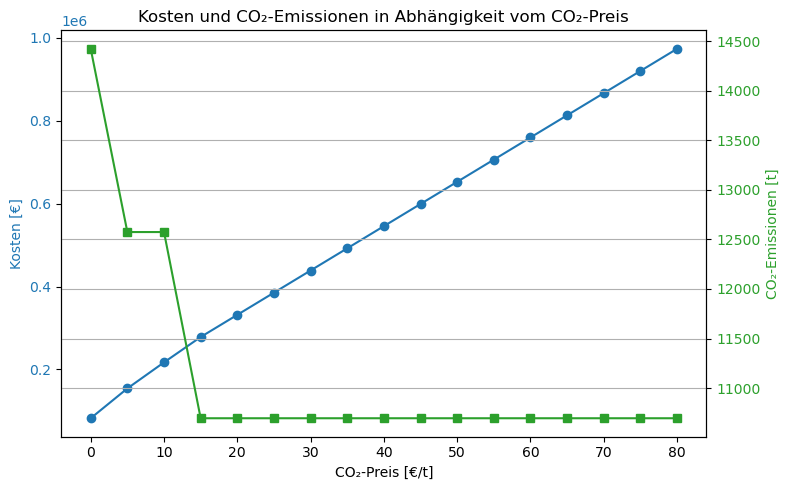

In [35]:
df_results = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Erste Achse: Kosten
color = 'tab:blue'
ax1.set_xlabel('CO₂-Preis [€/t]')
ax1.set_ylabel('Kosten [€]', color=color)
ax1.plot(df_results["CO2-Preis"], df_results["Kosten (€)"], marker='o', color=color, label='Kosten')
ax1.tick_params(axis='y', labelcolor=color)

# Zweite Achse: Emissionen
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('CO₂-Emissionen [t]', color=color)
ax2.plot(df_results["CO2-Preis"], df_results["Emissionen (t CO2)"], marker='s', color=color, label='Emissionen')
ax2.tick_params(axis='y', labelcolor=color)

# Titel und Layout
plt.title("Kosten und CO₂-Emissionen in Abhängigkeit vom CO₂-Preis")
fig.tight_layout()
plt.grid(True)
plt.show()

Ersichtlich ist, dass die CO2-Emissionen und die Gesamtkosten stark vom CO2-Preis abhängig sind. Ist dieser sehr gering, sind die Grenzkosten des Kohlekraftwerks sehr gering und die Energieerzeugung mittels Kohle ist billiger als die Erzeugung aus Gas, daher werden deutlich mehr Emissionen ausgestoßen. Steigt der CO2-Preis, ändert sich diese Reihenfolge wieder und ab **~15€/t** ist die Merit-Order wie bisher betrachtet wieder hergestellt - dieser Sprung ist in der grünen Kurve deutlich ersichtlich.

## Task 5 - Emissionsschranken und Dualität

### a) Duales System inkl. CO2-Schranke

**Primalmodell (mit Erneuerbaren, ohne Speicher, mit CO₂-Schranke)**

wie oben - jedoch vereinfacht

**Entscheidungsvariablen**

- $p_{i,t}$: Erzeugungsleistung von Kraftwerk $i$ zur Zeit $t$ [MW]  

**Parameter**

- $c_i$: Kosten pro MWh für Kraftwerk $i$ [€/MWh]  
- $e_i$: CO₂-Emissionen pro MWh von Kraftwerk $i$ [t/MWh]  
- $L_t$: Stromnachfrage in Stunde $t$ [MW]  
- $p_{i,t}^{\max}$: Maximale Erzeugungsleistung von Kraftwerk $i$ in Stunde $t$  
- $E^{\max}$: Maximal erlaubte CO₂-Emissionen im Zeitraum $[0, T]$ [t]  

**Zielfunktion**

Minimiere die Gesamtkosten:

$$
\min_{p_{i,t}} \sum_{t=1}^T \sum_{i=1}^N c_i \cdot p_{i,t}
$$

**Nebenbedingungen**

1. Lastdeckung:

$$
\sum_{i=1}^N p_{i,t} = L_t \quad \forall t
$$

2. Erzeugungsgrenzen:

$$
0 \leq p_{i,t} \leq p_{i,t}^{\max} \quad \forall i, t
$$

3. CO₂-Emissionsbegrenzung (neu):

$$
\sum_{t=1}^T \sum_{i=1}^N e_i \cdot p_{i,t} \leq E^{\max}
$$

---

**Dualmodell**

**Duale Variablen**

- $\lambda_t$: Schattenpreis für Lastdeckung in Stunde $t$  
- $\mu_{i,t} \geq 0$: Schattenpreis der oberen Leistungsgrenze $p_{i,t} \leq p_{i,t}^{\max}$  
- $\theta \geq 0$: Schattenpreis der Emissionsbeschränkung  

**Zielfunktion des Duals**

Maximiere:

$$
\max_{\lambda_t, \mu_{i,t}, \theta} \sum_{t=1}^T \lambda_t \cdot L_t - \sum_{t=1}^T \sum_{i=1}^N \mu_{i,t} \cdot p_{i,t}^{\max} - \theta \cdot E^{\max}
$$

**Nebenbedingungen**

Für alle $i, t$ gilt:

$$
\lambda_t - \mu_{i,t} - \theta \cdot e_i \leq c_i
$$

Zusätzlich:

$$
\mu_{i,t} \geq 0, \quad \theta \geq 0
$$


### b) kostenminimales primales Problem mit Zusatzbedingung

In [36]:
# Modell ohne Speicher verwendet!

CO2_price = 0  # €/t CO2
results = []

print(f"\n--- Optimierung für CO2-Preis: {CO2_price} €/t ---")

# Grenzkosten neu berechnen
mc_coal = fuelcost_coal / (eta_coal * H_coal) + (CO2_price * CO2_coal)
mc_gud  = fuelcost_gas / (eta_gud * H_ngas) + (CO2_price * CO2_gud)
mc_gas  = fuelcost_gas / (eta_gas * H_ngas) + (CO2_price * CO2_gas)
mc_PV = 0
mc_Wind = 0

kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
n_units = 5  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]


# Maximale Leistung pro Einheit (z.B. 100 MW)
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]
mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]

# Neues Modell erzeugen
model = gp.Model(f"Kraftwerk_CO2_{CO2_price}")
# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
        if i == 0:
            ub = power_wind[t]  # Wind
        elif i == 1:
            ub = power_PV[t]    # PV
        else:
            ub = p_max[i]       # Konstante für konventionelle Kraftwerke
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

# Lastdeckung
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

emissions_limit = 15000  # t CO2
model.addConstr(
    gp.quicksum(co2_faktoren[i] * p[i, t] for i in range(n_units) for t in range(T)) <= emissions_limit,
    name="CO2_limit"
)

# Zielfunktion: Kosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

model.optimize()

if model.status == GRB.OPTIMAL:
    total_cost = 0
    total_emissions = 0
    for t in range(T):
        for i in range(n_units):
            p_it = p[i, t].X
            total_cost += mc[i][t] * p_it
            total_emissions += co2_faktoren[i] * p_it
    print(f"Gesamtkosten: {total_cost:.2f} €")
    print(f"CO₂-Emissionen: {total_emissions:.2f} t")

    results.append({
        "CO2-Preis": CO2_price,
        "Kosten (€)": total_cost,
        "Emissionen (t CO2)": total_emissions
    })


--- Optimierung für CO2-Preis: 0 €/t ---
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 25 rows, 120 columns and 192 nonzeros
Model fingerprint: 0x14a3017e
Coefficient statistics:
  Matrix range     [3e-01, 1e+00]
  Objective range  [3e+00, 8e+00]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 2e+04]
Presolve removed 0 rows and 40 columns
Presolve time: 0.00s
Presolved: 25 rows, 80 columns, 152 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.8770926e+04   1.514723e+03   0.000000e+00      0s
      24    8.2381296e+04   0.000000e+00   0.000000e+00      0s

Solved in 24 iterations and 0.01 seconds (0.00 work units)
Optimal objective  8.238129581e+04
Gesamtkosten: 82381.30 €
CO₂-Emissionen: 14422.00 t


### c) Interpretation der Schattenvariable der Emissionsbeschränkung

Sie gibt an, wie stark sich die minimalen Gesamtkosten verändern würden, wenn man die zulässigen Emissionen um eine Tonne CO₂ erhöhen würde. 

---

**Mögliche Bedeutung**:

1. **Emissionsbeschränkung ist nicht bindend**  
   - Die tatsächlichen Emissionen liegen unter der erlaubten Grenze und Schattenvariable ist 0.  
   - Eine Erhöhung der Emissionsgrenze würde die Gesamtkosten nicht verändern.

2. **Emissionsbeschränkung ist bindend**  
   - Die Emissionen erreichen genau die erlaubte Grenze & Schattenvariable ist ungleich 0.  
   - Eine Erhöhung der Emissionsgrenze um 1 Tonne CO₂ würde die Kosten um den Wert der Schattenvariablen verringern. Die Schattenvariable entspricht hier dem impliziten CO₂-Preis, den das Modell für eine Tonne CO₂ "verlangt".

---

also:

- Die Schattenvariable der CO₂-Grenze zeigt den ökonomischen Wert einer zusätzlichen Tonne CO₂-Emission.  
- Ein Wert ungleich 0 bedeutet, dass die Emissionsbegrenzung kostenwirksam ist und eine Lockerung zu Kosteneinsparungen führen würde.


In [37]:
emission_constraint = model.getConstrByName("CO2_limit")
shadow_price = emission_constraint.Pi
print(f"Schattenvariable der Emissionsbeschränkung: {shadow_price:.2f} €/t CO2")

Schattenvariable der Emissionsbeschränkung: 0.00 €/t CO2


Daher: Die Nebenbedingung ist nicht bindend -> Emissionen liegen unter der Grenze.

### d) Schlussfolgerung Schattenvariable/duale Variable

**Zusammenhang zwischen Schattenpreis und CO₂-Preis**

- Die duale Variable (Schattenpreis) der Emissionsbeschränkung zeigt, wie stark sich die Gesamtkosten verändern, wenn die zulässige Menge an CO₂-Emissionen um eine Tonne erhöht oder gesenkt wird.
- Der Schattenpreis kann als ein impliziter CO₂-Preis verstanden werden, den das Modell „bezahlt“, um unter der vorgegebenen Emissionsgrenze zu bleiben.
- Wird im Modell zusätzlich ein externer CO₂-Preis (z. B. über Steuern oder Zertifikate) eingeführt, wäre es aus Effizienzsicht sinnvoll, wenn dieser mit dem Schattenpreis übereinstimmt.
- Ist der Schattenpreis niedrig oder null, bedeutet das, dass die Emissionsgrenze nicht bindend ist – sie hat also keinen Einfluss auf das Ergebnis.
- Ein hoher Schattenpreis hingegen zeigt, dass die CO₂-Grenze die Optimierung stark beeinflusst. Eine zusätzliche Tonne CO₂ würde deutliche Mehrkosten verursachen.

**Anwendung in der Klimapolitik**

- **Ableitung eines ökonomisch sinnvollen CO₂-Preises:**  
  Der Schattenpreis kann als Orientierung dienen, welcher CO₂-Preis volkswirtschaftlich effizient wäre – also bei welchem Preis die Emissionsziele mit minimalen Kosten erreicht werden.

- **Zielführende Lenkung durch CO₂-Bepreisung:**  
  Ein CO₂-Preis, der in etwa dem Schattenpreis entspricht, setzt sinnvolle Anreize für emissionsärmeres Verhalten und Investitionen in saubere Technologien.

- **Überprüfung politischer Emissionsziele:**  
  Ist der Schattenpreis extrem hoch, kann das darauf hindeuten, dass das gesetzte Emissionsziel ökonomisch schwer umsetzbar ist. Dann sollte geprüft werden, ob Anpassungen sinnvoll sind – z. B. durch mehr technologische Unterstützung oder schrittweise Zielverschärfungen.

- **Transparenz und Planungssicherheit:**  
  Unternehmen erhalten durch einen CO₂-Preis in Höhe des Schattenpreises ein verlässliches Signal, auf dessen Basis Investitionen in Dekarbonisierung besser planbar sind.

